# 🚀 Introduction to Transformers & Tokenization

**Week 8-9: LLM Fundamentals & Prompt Engineering**

This notebook introduces the foundational concepts of transformers and tokenization. By the end, you'll understand:
- How the transformer architecture works
- The difference between encoders and decoders
- How tokenization works and why it matters
- How to visualize attention patterns

---


<a name="setup"></a>
## 1. Setup & Installation

Run this cell to install required libraries:

In [ ]:
# Install required libraries
!pip install transformers torch bertviz matplotlib seaborn --quiet

print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.7 MB/s eta 0:00:00
✅ Installation complete!


In [ ]:
# Import libraries
import torch
import transformers
from transformers import (
    AutoTokenizer,
    AutoModel,
    BertTokenizer,
    BertModel,
    pipeline
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import HTML

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🤗 Transformers version: {transformers.__version__}")

✅ Imports successful!
🔥 PyTorch version: 2.10.0+cpu
🤗 Transformers version: 5.0.0


<a name="architecture"></a>
## 2. The Transformer Architecture

### 2.1 What Makes Transformers Special?

Transformers, introduced in the paper ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) (2017), revolutionized NLP through:

| Feature | RNN/LSTM | Transformer |
|---------|----------|-------------|
| **Processing** | Sequential | Parallel |
| **Long-range dependencies** | Difficult | Easy (attention) |
| **Training speed** | Slow | Fast |
| **Context understanding** | Limited | Global |

### 2.2 Core Components

```
┌─────────────────────────────────────────────────────────────┐
│                    TRANSFORMER ARCHITECTURE                  │
├─────────────────────────────────────────────────────────────┤
│  INPUT → [Tokenization] → [Embeddings] → [Positional Encoding] │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │              ENCODER (Left Stack)                    │    │
│  │  ┌─────────────┐    ┌─────────────┐    ┌─────────┐  │    │
│  │  │ Multi-Head  │ → │  Feed       │ → │  Add &  │  │    │
│  │  │ Attention   │    │  Forward    │    │  Norm   │  │    │
│  │  └─────────────┘    └─────────────┘    └─────────┘  │    │
│  │         ↑ (repeated N times)                         │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │              DECODER (Right Stack)                   │    │
│  │  ┌─────────────┐    ┌─────────────┐    ┌─────────┐  │    │
│  │  │ Masked      │ → │ Cross-      │ → │  Add &  │  │    │
│  │  │ Attention   │    │ Attention   │    │  Norm   │  │    │
│  │  └─────────────┘    └─────────────┘    └─────────┘  │    │
│  │         ↑ (repeated N times)                         │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  OUTPUT → [Linear] → [Softmax] → Probabilities              │
└─────────────────────────────────────────────────────────────┘
```

### 2.3 Encoder vs Decoder vs Encoder-Decoder

Let's visualize the different architectures:

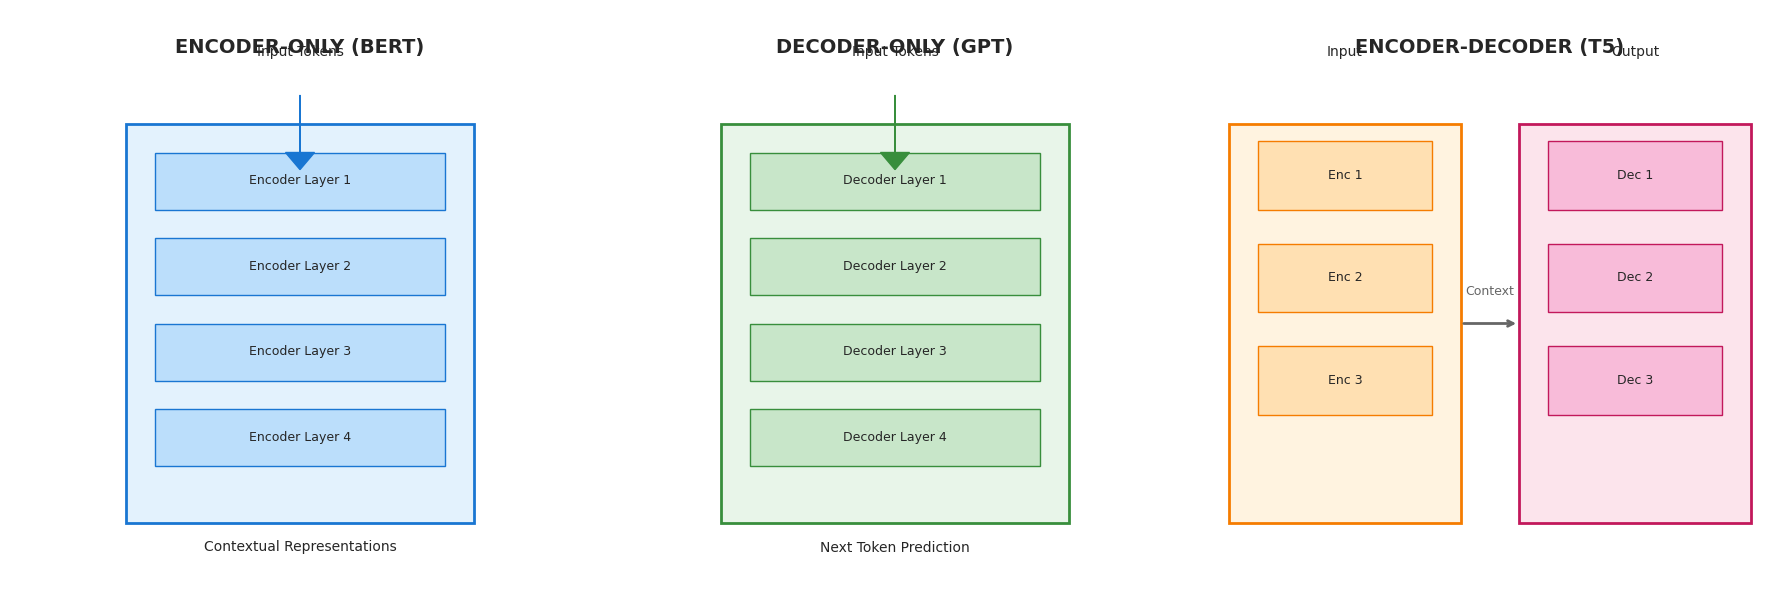


📊 Architecture Comparison:
BERT         | Encoder    | Understanding   | Bidirectional
GPT          | Decoder    | Generation      | Left-to-Right
T5           | Enc-Dec    | Translation     | Bidir → Left-to-Right
RoBERTa      | Encoder    | Understanding   | Bidirectional
LLaMA        | Decoder    | Generation      | Left-to-Right


In [ ]:
# Visualize transformer architectures
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Encoder-Only (BERT)
ax = axes[0]
ax.text(0.5, 0.95, 'ENCODER-ONLY (BERT)', ha='center', va='top', fontsize=14, fontweight='bold')
ax.add_patch(plt.Rectangle((0.2, 0.1), 0.6, 0.7, fill=True, facecolor='#E3F2FD', edgecolor='#1976D2', linewidth=2))
for i in range(4):
    y = 0.65 - i * 0.15
    ax.add_patch(plt.Rectangle((0.25, y), 0.5, 0.1, fill=True, facecolor='#BBDEFB', edgecolor='#1976D2'))
    ax.text(0.5, y + 0.05, f'Encoder Layer {i+1}', ha='center', va='center', fontsize=9)
ax.arrow(0.5, 0.85, 0, -0.1, head_width=0.05, head_length=0.03, fc='#1976D2', ec='#1976D2')
ax.text(0.5, 0.92, 'Input Tokens', ha='center', fontsize=10)
ax.text(0.5, 0.05, 'Contextual Representations', ha='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Decoder-Only (GPT)
ax = axes[1]
ax.text(0.5, 0.95, 'DECODER-ONLY (GPT)', ha='center', va='top', fontsize=14, fontweight='bold')
ax.add_patch(plt.Rectangle((0.2, 0.1), 0.6, 0.7, fill=True, facecolor='#E8F5E9', edgecolor='#388E3C', linewidth=2))
for i in range(4):
    y = 0.65 - i * 0.15
    ax.add_patch(plt.Rectangle((0.25, y), 0.5, 0.1, fill=True, facecolor='#C8E6C9', edgecolor='#388E3C'))
    ax.text(0.5, y + 0.05, f'Decoder Layer {i+1}', ha='center', va='center', fontsize=9)
ax.arrow(0.5, 0.85, 0, -0.1, head_width=0.05, head_length=0.03, fc='#388E3C', ec='#388E3C')
ax.text(0.5, 0.92, 'Input Tokens', ha='center', fontsize=10)
ax.text(0.5, 0.05, 'Next Token Prediction', ha='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Encoder-Decoder (T5)
ax = axes[2]
ax.text(0.5, 0.95, 'ENCODER-DECODER (T5)', ha='center', va='top', fontsize=14, fontweight='bold')
# Encoder
ax.add_patch(plt.Rectangle((0.05, 0.1), 0.4, 0.7, fill=True, facecolor='#FFF3E0', edgecolor='#F57C00', linewidth=2))
for i in range(3):
    y = 0.65 - i * 0.18
    ax.add_patch(plt.Rectangle((0.1, y), 0.3, 0.12, fill=True, facecolor='#FFE0B2', edgecolor='#F57C00'))
    ax.text(0.25, y + 0.06, f'Enc {i+1}', ha='center', va='center', fontsize=9)
# Decoder
ax.add_patch(plt.Rectangle((0.55, 0.1), 0.4, 0.7, fill=True, facecolor='#FCE4EC', edgecolor='#C2185B', linewidth=2))
for i in range(3):
    y = 0.65 - i * 0.18
    ax.add_patch(plt.Rectangle((0.6, y), 0.3, 0.12, fill=True, facecolor='#F8BBD9', edgecolor='#C2185B'))
    ax.text(0.75, y + 0.06, f'Dec {i+1}', ha='center', va='center', fontsize=9)
# Connection
ax.annotate('', xy=(0.55, 0.45), xytext=(0.45, 0.45),
            arrowprops=dict(arrowstyle='->', lw=2, color='#666'))
ax.text(0.5, 0.5, 'Context', ha='center', fontsize=9, color='#666')
ax.text(0.25, 0.92, 'Input', ha='center', fontsize=10)
ax.text(0.75, 0.92, 'Output', ha='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Architecture Comparison:")
print("=" * 60)
comparison_data = {
    'Model': ['BERT', 'GPT', 'T5', 'RoBERTa', 'LLaMA'],
    'Type': ['Encoder', 'Decoder', 'Enc-Dec', 'Encoder', 'Decoder'],
    'Best For': ['Understanding', 'Generation', 'Translation', 'Understanding', 'Generation'],
    'Direction': ['Bidirectional', 'Left-to-Right', 'Bidir → Left-to-Right', 'Bidirectional', 'Left-to-Right']
}

for i in range(len(comparison_data['Model'])):
    print(f"{comparison_data['Model'][i]:<12} | {comparison_data['Type'][i]:<10} | {comparison_data['Best For'][i]:<15} | {comparison_data['Direction'][i]}")

<a name="tokenization"></a>
## 3. Tokenization Deep Dive

Tokenization is the process of converting text into tokens that the model can process. Different models use different tokenizers!

### 3.1 Types of Tokenization

In [ ]:
# Compare different tokenizers
test_sentences = [
    "Hello world!",
    "Tokenization is fascinating!",
    "ChatGPT uses BPE tokenization.",
    "Hugging Face 🤗 makes NLP easy.",
    "The price is $49.99"
]

# Load different tokenizers
tokenizers = {
    'BERT (WordPiece)': BertTokenizer.from_pretrained('bert-base-uncased'),
    'GPT-2 (BPE)': AutoTokenizer.from_pretrained('gpt2'),
    'T5 (SentencePiece)': AutoTokenizer.from_pretrained('t5-small'),
}

print("🔤 Tokenization Comparison\n")
print("=" * 80)

for sentence in test_sentences:
    print(f"\n📄 Text: '{sentence}'\n")
    for name, tokenizer in tokenizers.items():
        tokens = tokenizer.tokenize(sentence)
        token_ids = tokenizer.encode(sentence)
        print(f"  {name:<25} → {len(tokens):2d} tokens: {tokens}")
    print("-" * 80)

🔤 Tokenization Comparison


📄 Text: 'Hello world!'

  BERT (WordPiece)          →  3 tokens: ['hello', 'world', '!']
  GPT-2 (BPE)               →  3 tokens: ['Hello', 'Ġworld', '!']
  T5 (SentencePiece)        →  3 tokens: ['▁Hello', '▁world', '!']
--------------------------------------------------------------------------------

📄 Text: 'Tokenization is fascinating!'

  BERT (WordPiece)          →  5 tokens: ['token', '##ization', 'is', 'fascinating', '!']
  GPT-2 (BPE)               →  5 tokens: ['Token', 'ization', 'Ġis', 'Ġfascinating', '!']
  T5 (SentencePiece)        →  6 tokens: ['▁To', 'ken', 'ization', '▁is', '▁fascinating', '!']
--------------------------------------------------------------------------------

📄 Text: 'ChatGPT uses BPE tokenization.'

  BERT (WordPiece)          →  9 tokens: ['chat', '##gp', '##t', 'uses', 'bp', '##e', 'token', '##ization', '.']
  GPT-2 (BPE)               →  9 tokens: ['Chat', 'G', 'PT', 'Ġuses', 'ĠB', 'PE', 'Ġtoken', 'ization', '.']
  T5 (Se

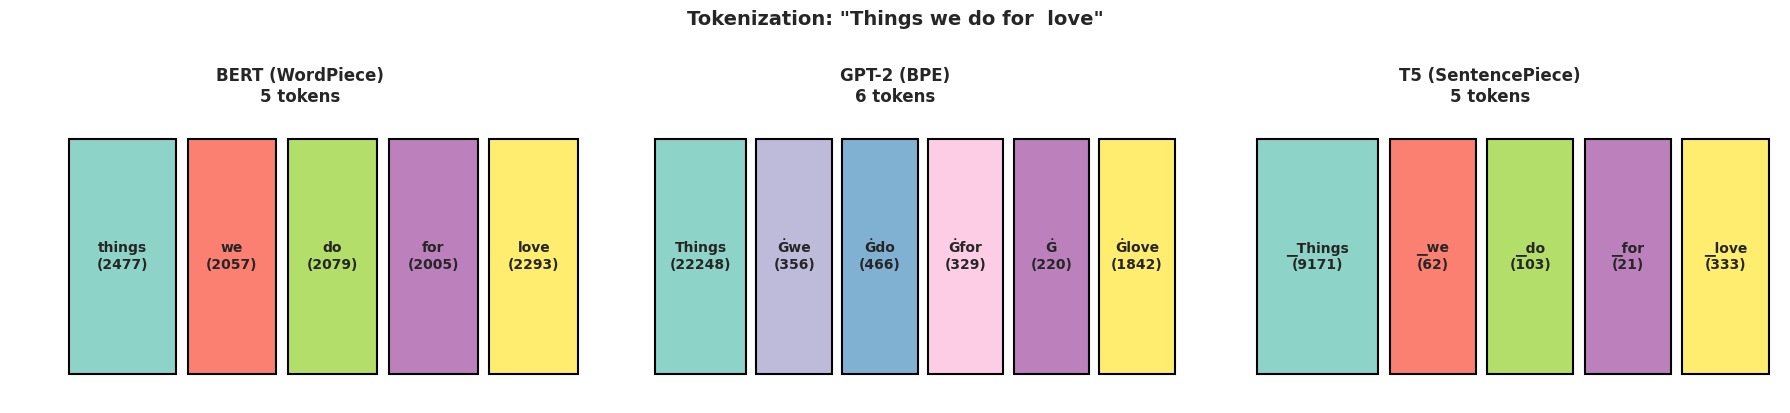

In [ ]:
# Visualize tokenization for a single example
text = "Things we do for  love"

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, (name, tokenizer) in enumerate(tokenizers.items()):
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    ax = axes[idx]
    colors = plt.cm.Set3(np.linspace(0, 1, len(tokens)))

    # Create colored token visualization
    x_pos = 0
    for i, (token, token_id) in enumerate(zip(tokens, token_ids)):
        width = max(0.15, len(token) * 0.03)
        ax.barh(0, width, left=x_pos, color=colors[i], edgecolor='black', linewidth=1.5)
        ax.text(x_pos + width/2, 0, token + f"\n({token_id})",
                ha='center', va='center', fontsize=10, fontweight='bold')
        x_pos += width + 0.02

    ax.set_xlim(-0.1, x_pos)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(f'{name}\n{len(tokens)} tokens', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Tokenization: "{text}"', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Special Tokens

Each tokenizer has special tokens with specific meanings:

In [ ]:
# Explore special tokens
print("🔑 Special Tokens by Model\n")
print("=" * 70)

for name, tokenizer in tokenizers.items():
    print(f"\n📦 {name}:")
    print("-" * 40)

    special_tokens = {
        'CLS (Classification)': getattr(tokenizer, 'cls_token', 'N/A'),
        'SEP (Separator)': getattr(tokenizer, 'sep_token', 'N/A'),
        'PAD (Padding)': getattr(tokenizer, 'pad_token', 'N/A'),
        'UNK (Unknown)': getattr(tokenizer, 'unk_token', 'N/A'),
        'MASK': getattr(tokenizer, 'mask_token', 'N/A'),
        'BOS (Beginning)': getattr(tokenizer, 'bos_token', 'N/A'),
        'EOS (End)': getattr(tokenizer, 'eos_token', 'N/A'),
    }

    for token_name, token_value in special_tokens.items():
        if token_value and token_value != 'N/A':
            token_id = tokenizer.convert_tokens_to_ids(token_value) if token_value else 'N/A'
            print(f"  {token_name:<25} {str(token_value):<15} (ID: {token_id})")

🔑 Special Tokens by Model


📦 BERT (WordPiece):
----------------------------------------
  CLS (Classification)      [CLS]           (ID: 101)
  SEP (Separator)           [SEP]           (ID: 102)
  PAD (Padding)             [PAD]           (ID: 0)
  UNK (Unknown)             [UNK]           (ID: 100)
  MASK                      [MASK]          (ID: 103)

📦 GPT-2 (BPE):
----------------------------------------
  UNK (Unknown)             <|endoftext|>   (ID: 50256)
  BOS (Beginning)           <|endoftext|>   (ID: 50256)
  EOS (End)                 <|endoftext|>   (ID: 50256)

📦 T5 (SentencePiece):
----------------------------------------
  PAD (Padding)             <pad>           (ID: 0)
  UNK (Unknown)             <unk>           (ID: 2)
  EOS (End)                 </s>            (ID: 1)


<a name="attention"></a>
## 4. Attention Visualization

Attention is the key mechanism that makes transformers powerful. Let's visualize how it works!

In [ ]:
# Install bertviz if not present
!pip install bertviz --quiet

# Use bertviz for attention visualization
from bertviz import head_view, model_view

# Load BERT model and tokenizer
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Prepare input
sentence = "The cat sat on the mat"
inputs = tokenizer(sentence, return_tensors='pt', add_special_tokens=True)
input_ids = inputs['input_ids']

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)
    attention = outputs.attentions

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
print("📝 Tokens:", tokens)
print(f"\n🔍 Number of attention layers: {len(attention)}")
print(f"👀 Attention heads per layer: {attention[0].shape[1]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📝 Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']

🔍 Number of attention layers: 12
👀 Attention heads per layer: 12


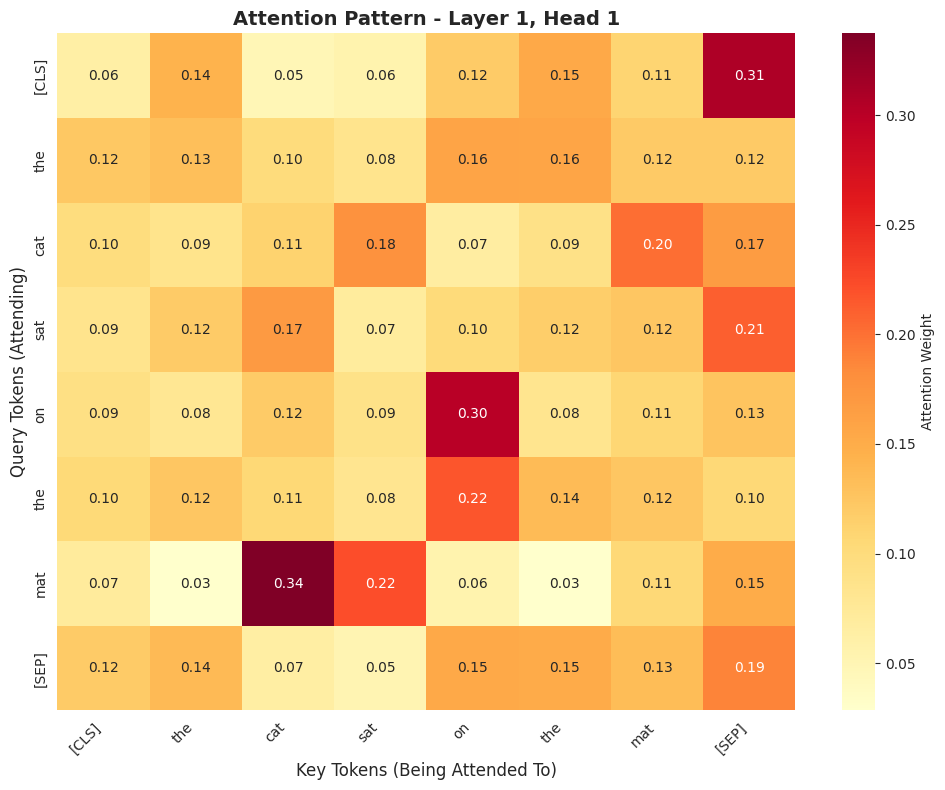

In [ ]:
# Visualize attention as a heatmap
def plot_attention_heatmap(attention_weights, tokens, layer_idx=0, head_idx=0):
    """Plot attention heatmap for a specific layer and head."""
    attn = attention_weights[layer_idx][0, head_idx].numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='YlOrRd',
                annot=True,
                fmt='.2f',
                cbar_kws={'label': 'Attention Weight'})
    plt.title(f'Attention Pattern - Layer {layer_idx + 1}, Head {head_idx + 1}', fontsize=14, fontweight='bold')
    plt.xlabel('Key Tokens (Being Attended To)', fontsize=12)
    plt.ylabel('Query Tokens (Attending)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Visualize first layer, first head
plot_attention_heatmap(attention, tokens, layer_idx=0, head_idx=0)

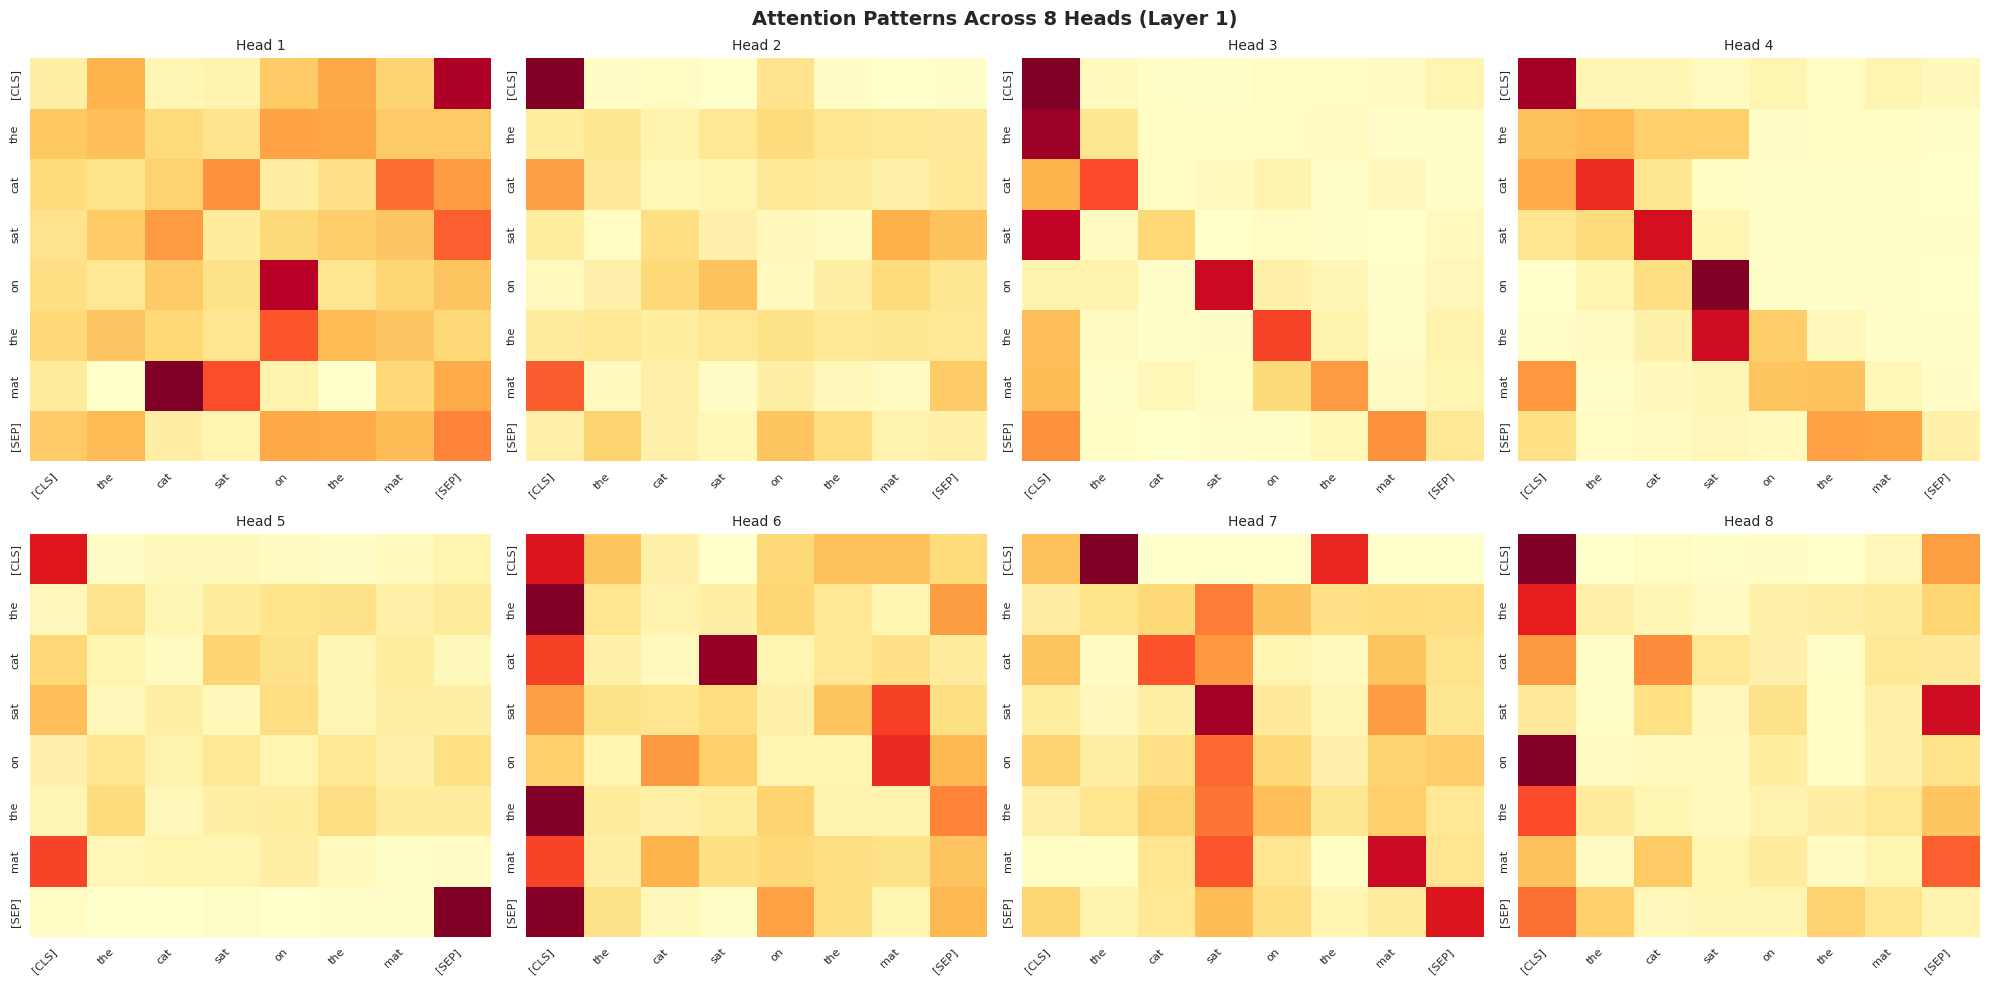


ံ Observation: Different heads learn different attention patterns!
   - Some focus on adjacent words
   - Some focus on specific relationships (subject-verb, etc.)
   - This is the power of multi-head attention!


In [ ]:
# Ensure model and data are prepared
# Using the standard tokenizer call instead of encode_plus
inputs = tokenizer("The cat sat on the mat", return_tensors='pt', add_special_tokens=True)
with torch.no_grad():
    outputs = model(**inputs)
    attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Compare attention patterns across different heads
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for head_idx in range(8):
    # Get attention for the first (and only) batch item and specific head
    attn = attention[0][0, head_idx].numpy()

    ax = axes[head_idx]
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
                cmap='YlOrRd', ax=ax, cbar=False)
    ax.set_title(f'Head {head_idx + 1}', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.suptitle('Attention Patterns Across 8 Heads (Layer 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nံ Observation: Different heads learn different attention patterns!")
print("   - Some focus on adjacent words")
print("   - Some focus on specific relationships (subject-verb, etc.)")
print("   - This is the power of multi-head attention!")

<a name="context"></a>
## 5. Context Windows

The context window determines how much text the model can process at once.

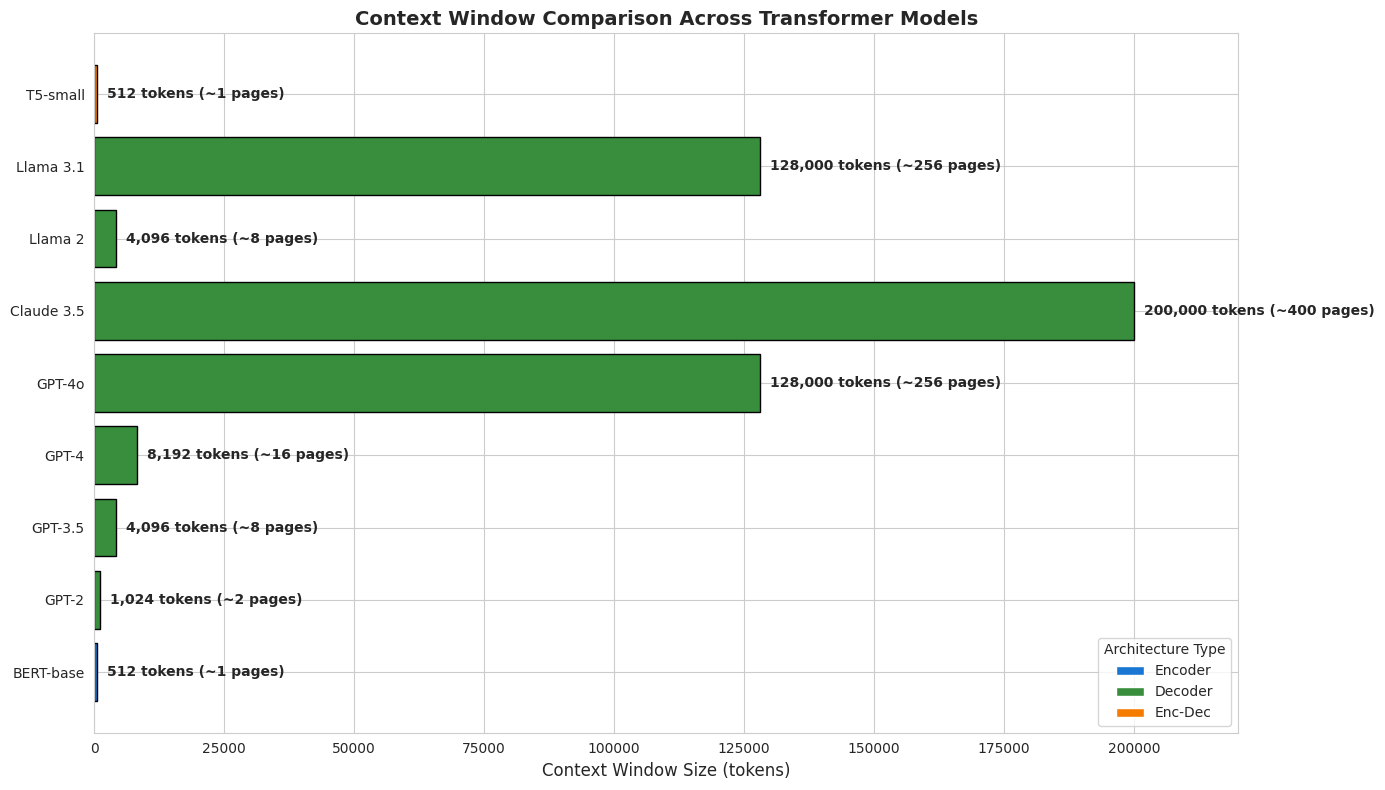


📏 Context Window Insights:
• Early models (BERT, GPT-2): 512-1024 tokens (~1 page)
• Modern LLMs (GPT-4, Claude): 128K-200K tokens (~250-400 pages)
• Larger context = can process entire documents
• Trade-off: Larger context = more memory & compute


In [ ]:
# Compare context window sizes
context_data = {
    'Model': ['BERT-base', 'GPT-2', 'GPT-3.5', 'GPT-4', 'GPT-4o', 'Claude 3.5', 'Llama 2', 'Llama 3.1', 'T5-small'],
    'Context Window (tokens)': [512, 1024, 4096, 8192, 128000, 200000, 4096, 128000, 512],
    'Type': ['Encoder', 'Decoder', 'Decoder', 'Decoder', 'Decoder', 'Decoder', 'Decoder', 'Decoder', 'Enc-Dec']
}

# Calculate approximate pages (assuming ~500 tokens/page)
pages = [cw / 500 for cw in context_data['Context Window (tokens)']]

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

colors = {'Encoder': '#1976D2', 'Decoder': '#388E3C', 'Enc-Dec': '#F57C00'}
bar_colors = [colors[t] for t in context_data['Type']]

bars = ax.barh(context_data['Model'], context_data['Context Window (tokens)'], color=bar_colors, edgecolor='black')

# Add value labels
for i, (bar, tokens, page) in enumerate(zip(bars, context_data['Context Window (tokens)'], pages)):
    width = bar.get_width()
    label = f'{tokens:,} tokens (~{page:.0f} pages)' if page >= 1 else f'{tokens:,} tokens (~{page:.1f} pages)'
    ax.text(width + 2000, bar.get_y() + bar.get_height()/2, label,
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Context Window Size (tokens)', fontsize=12)
ax.set_title('Context Window Comparison Across Transformer Models', fontsize=14, fontweight='bold')
ax.set_xlim(0, 220000)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[t], label=t) for t in colors]
ax.legend(handles=legend_elements, loc='lower right', title='Architecture Type')

plt.tight_layout()
plt.show()

print("\n📏 Context Window Insights:")
print("=" * 50)
print("• Early models (BERT, GPT-2): 512-1024 tokens (~1 page)")
print("• Modern LLMs (GPT-4, Claude): 128K-200K tokens (~250-400 pages)")
print("• Larger context = can process entire documents")
print("• Trade-off: Larger context = more memory & compute")